Reading data

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (6607, 20)

First 5 Rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Data cleaning

In [38]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nDataset After Cleaning:", df.shape)

Missing Values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Duplicates:
0

Dataset After Cleaning: (6607, 20)


statistics

In [39]:
display(df.describe())

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Exam Mark Distribution

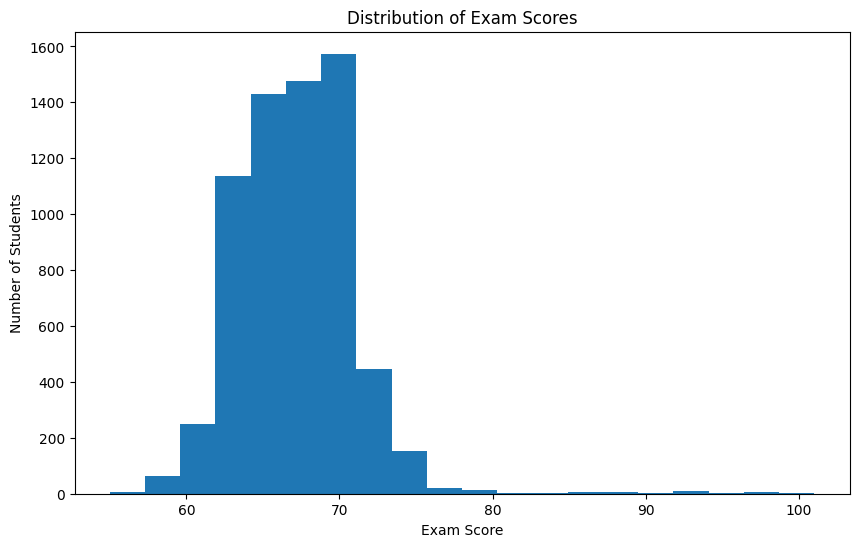

In [40]:
plt.figure(figsize=(10, 6))

plt.hist(df["Exam_Score"], bins=20)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

Studying and Its Impact

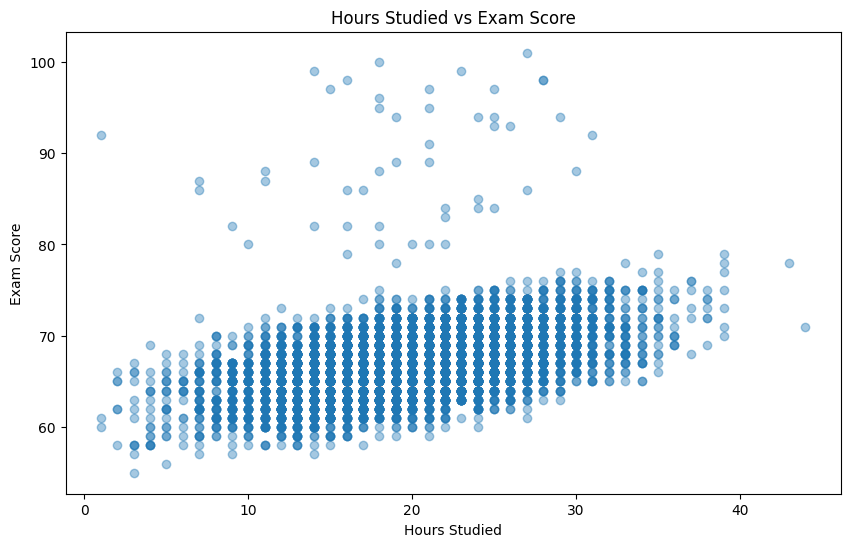

In [41]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Hours_Studied"],
    df["Exam_Score"],
    alpha=0.4
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

Presence and Its Impact

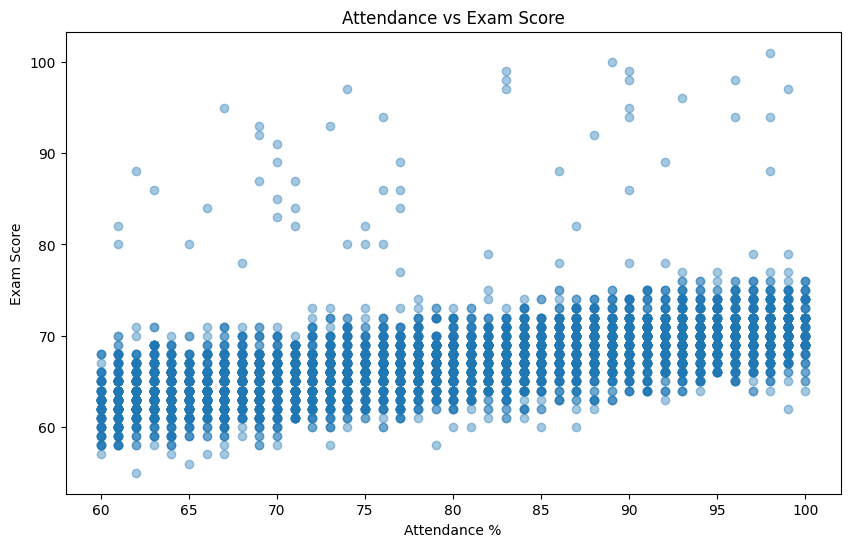

In [42]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Attendance"],
    df["Exam_Score"],
    alpha=0.4
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance %")
plt.ylabel("Exam Score")

plt.show()

Private lessons

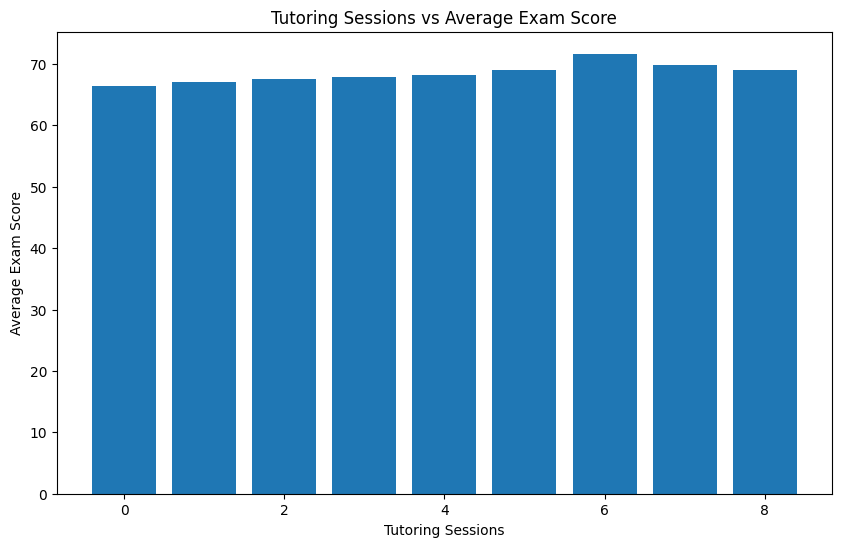

In [43]:
tutoring = df.groupby("Tutoring_Sessions")["Exam_Score"].mean()

plt.figure(figsize=(10, 6))

plt.bar(
    tutoring.index,
    tutoring.values
)

plt.title("Tutoring Sessions vs Average Exam Score")
plt.xlabel("Tutoring Sessions")
plt.ylabel("Average Exam Score")

plt.show()

SQL

In [44]:
import sqlite3

conn = sqlite3.connect("student_performance.db")

df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("SQL Database Created Successfully!")

SQL Database Created Successfully!


Average score

In [45]:
query = """
SELECT AVG(Exam_Score) AS Average_Exam_Score
FROM students
"""

result = pd.read_sql(query, conn)

display(result)

,Average_Exam_Score
0,67.235659


Students with low grades (<60)

In [46]:
query = """
SELECT *
FROM students
WHERE Exam_Score < 60
ORDER BY Exam_Score ASC
"""

low_students = pd.read_sql(query, conn)

display(low_students.head(20))

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,3,62,Medium,Low,No,6,67,Medium,Yes,1,Low,Medium,Public,Negative,3,No,High School,Near,Male,55
1,5,65,Low,High,No,7,71,Medium,Yes,0,Low,Medium,Private,Negative,2,No,College,Far,Male,56
2,7,66,High,Low,Yes,8,68,High,Yes,0,Low,Medium,Public,Negative,2,Yes,College,Moderate,Male,57
3,14,67,Low,Low,Yes,7,66,Low,Yes,0,Low,Medium,Public,Neutral,4,No,High School,Far,Female,57
4,9,64,Medium,Low,Yes,10,68,Low,Yes,0,Medium,Medium,Private,Negative,3,No,High School,Near,Male,57
5,3,60,Medium,Low,Yes,6,78,Low,Yes,1,Low,Medium,Public,Positive,1,No,Postgraduate,Near,Female,57
6,4,69,Medium,Low,No,9,93,Low,No,2,Medium,High,Private,Negative,3,No,High School,Moderate,Female,58
7,13,61,High,Low,No,7,68,Low,No,1,Medium,Medium,Public,Neutral,2,No,High School,Near,Male,58
8,4,61,Low,High,Yes,7,71,High,Yes,0,Low,Low,Public,Positive,1,No,Postgraduate,Near,Male,58
9,14,61,Medium,Medium,No,5,82,Low,No,0,Low,Medium,Public,Neutral,0,No,High School,Near,Female,58


The impact of study hours

In [47]:
query = """
SELECT
    Hours_Studied,
    AVG(Exam_Score) AS Average_Score,
    COUNT(*) AS Number_of_Students
FROM students
GROUP BY Hours_Studied
ORDER BY Hours_Studied
"""

study_analysis = pd.read_sql(query, conn)

display(study_analysis)

,Hours_Studied,Average_Score,Number_of_Students
0,1,71.000000,3
1,2,63.000000,6
2,3,61.333333,12
3,4,61.647059,17
4,5,62.857143,21
5,6,63.470588,17
6,7,64.352941,51
7,8,64.155172,58
8,9,64.162791,86
9,10,64.393617,94


The impact of attendance

In [48]:
query = """
SELECT
    Attendance,
    AVG(Exam_Score) AS Average_Score
FROM students
GROUP BY Attendance
ORDER BY Attendance
"""

attendance_analysis = pd.read_sql(query, conn)

display(attendance_analysis)

,Attendance,Average_Score
0,60,62.413793
1,61,63.384146
2,62,63.756579
3,63,64.361290
4,64,63.884615
5,65,63.905063
6,66,64.537931
7,67,64.626316
8,68,65.147059
9,69,65.123529


Machine learning

In [49]:
X = df.drop(columns=["Exam_Score"])

y = df["Exam_Score"]

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Numerical Columns:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']


Test / Train model machine

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numerical",
            "passthrough",
            numerical_columns
        )
    ]
)

Data partitioning


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5285, 19)
Testing Data: (1322, 19)


Linear Regression

In [52]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("===== Linear Regression =====")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R2 Score:", round(linear_r2, 2))

===== Linear Regression =====
MAE: 0.45
RMSE: 1.8
R2 Score: 0.77


Random Forest

In [53]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=15,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("===== Random Forest =====")
print("MAE:", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2 Score:", round(rf_r2, 2))

===== Random Forest =====
MAE: 1.06
RMSE: 2.12
R2 Score: 0.68


Model Comparison

In [36]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Actual vs Predicted

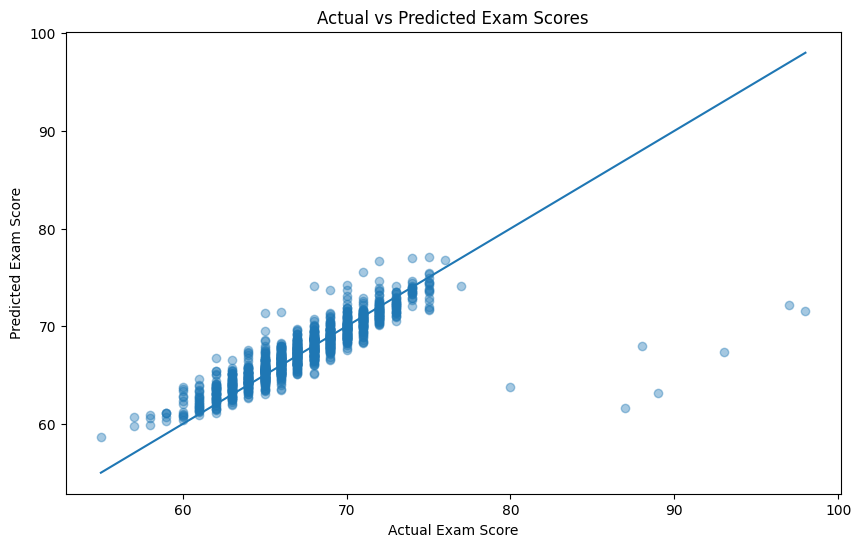

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.title("Actual vs Predicted Exam Scores")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.show()

Feature Importance

In [55]:
preprocessor_fitted = rf_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

rf = rf_model.named_steps["model"]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
38,numerical__Attendance,0.412488
37,numerical__Hours_Studied,0.253241
40,numerical__Previous_Scores,0.080297
41,numerical__Tutoring_Sessions,0.032262
3,categorical__Access_to_Resources_High,0.020331
0,categorical__Parental_Involvement_High,0.019378
39,numerical__Sleep_Hours,0.018917
42,numerical__Physical_Activity,0.018694
1,categorical__Parental_Involvement_Low,0.012239
4,categorical__Access_to_Resources_Low,0.010683


Drawing of important 15 factor

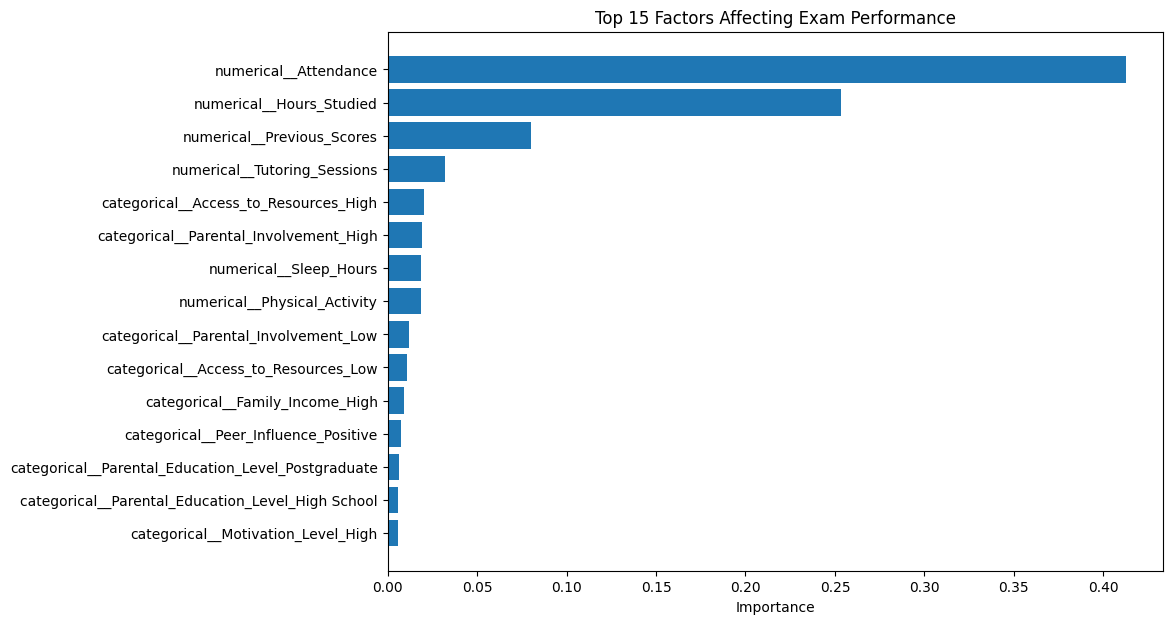

In [56]:
top_features = importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Factors Affecting Exam Performance")
plt.xlabel("Importance")

plt.show()

Prediction for a new student

In [69]:
new_student = pd.DataFrame({
    "Hours_Studied": [35],
    "Attendance": [100],
    "Parental_Involvement": ["High"],
    "Access_to_Resources": ["Medium"],
    "Extracurricular_Activities": ["Yes"],
    "Sleep_Hours": [8],
    "Previous_Scores": [100],
    "Motivation_Level": ["High"],
    "Internet_Access": ["Yes"],
    "Tutoring_Sessions": [3],
    "Family_Income": ["High"],
    "Teacher_Quality": ["High"],
    "School_Type": ["Private"],
    "Peer_Influence": ["Neutral"],
    "Physical_Activity": [20],
    "Learning_Disabilities": ["Yes"],
    "Parental_Education_Level": ["High School"],
    "Distance_from_Home": ["Near"],
    "Gender": ["Male"]
})

predicted_score = rf_model.predict(new_student)[0]

score = round(predicted_score)

print("Predicted Exam Score:", score)

Predicted Exam Score: 81


In [58]:
if score < 60:
    risk = "High Risk"
elif score < 70:
    risk = "Medium Risk"
else:
    risk = "Low Risk"

print("Risk Level:", risk)

Risk Level: Medium Risk


In [59]:
print("\n==============================")
print("Personalized Student Advice")
print("==============================")

advice_given = False

if new_student["Hours_Studied"].iloc[0] < 15:
    print(" Try to increase your study time gradually.")
    advice_given = True

if new_student["Attendance"].iloc[0] < 75:
    print(" Try to improve your attendance.")
    advice_given = True

if new_student["Previous_Scores"].iloc[0] < 60:
    print(" Review previous topics and focus on weak subjects.")
    advice_given = True

if new_student["Sleep_Hours"].iloc[0] < 7:
    print(" Try to maintain a regular sleep schedule.")
    advice_given = True

if new_student["Tutoring_Sessions"].iloc[0] < 2:
    print(" Consider getting additional academic support.")
    advice_given = True

if new_student["Motivation_Level"].iloc[0] == "Low":
    print(" Set small study goals and track your progress.")
    advice_given = True

if new_student["Parental_Involvement"].iloc[0] == "Low":
    print(" Having more family support may help with your studies.")
    advice_given = True

if new_student["Access_to_Resources"].iloc[0] == "Low":
    print(" Try to make better use of available learning resources.")
    advice_given = True

if not advice_given:
    print(" Great job! Keep maintaining your current study habits.")

print("\nKeep improving step by step! ")


Personalized Student Advice
 Try to improve your attendance.
 Review previous topics and focus on weak subjects.
 Try to maintain a regular sleep schedule.
 Consider getting additional academic support.
 Set small study goals and track your progress.
 Having more family support may help with your studies.

Keep improving step by step! 
